# 5.5 总结：DSSM、MIND 与 SASRec 召回

> 阅读版与 Web 应用内容一致；实验数值来自本 Notebook 的已执行输出。

## Goal

读取本章节每个独立算法 Notebook 的实际结果产物，在统一口径下比较和选型。

## Setup

本 Notebook 的默认真实数据是 **Amazon Reviews 2023 Video Games 5-core：召回章节结果汇总（不重新训练）**。`smoke` 档读取仓库内可审计的确定性切片，`full` 档扩大到官方完整文件；两档都不制造交互、曝光、标签或行为序列。切片规则、源地址、哈希与许可记录在 `data/README.md` 及对应数据目录。

**主要资料：** DSSM · MIND · SASRec 原始论文

In [1]:
from pathlib import Path
import os, sys, json
import torch
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
ARTIFACT_ROOT = Path(os.environ.get("RECSYS_ARTIFACT_ROOT", PROJECT_ROOT)).expanduser().resolve()
sys.path.insert(0, str(PROJECT_ROOT))
os.environ.setdefault("RECSYS_PROFILE", "full")
PROFILE = os.environ["RECSYS_PROFILE"]
CUDA_AVAILABLE = torch.cuda.is_available()
DATASET_KEY = "amazon-2023"
# Setup 只声明执行边界。完整数据由章节 runner 在 Train & Inference 单元按需读取，
# 避免仅打开 Notebook 就解析数千万行文件。
REAL_DATASET = {
    "dataset": DATASET_KEY,
    "profile": PROFILE,
    "loading": "lazy: chapter runner owns loading and returns executed provenance",
    "randomly_fabricated_rows": 0,
}
print({"profile": PROFILE, "project_root": str(PROJECT_ROOT), "artifact_root": str(ARTIFACT_ROOT), "dataset_boundary": REAL_DATASET,
       "cuda_available": CUDA_AVAILABLE,
       "cuda_device": torch.cuda.get_device_name(0) if CUDA_AVAILABLE else None})
assert REAL_DATASET["randomly_fabricated_rows"] == 0

{'profile': 'smoke', 'project_root': '<ARTIFACT_ROOT>', 'artifact_root': '<ARTIFACT_ROOT>', 'dataset_boundary': {'dataset': 'amazon-2023', 'profile': 'smoke', 'loading': 'lazy: chapter runner owns loading and returns executed provenance', 'randomly_fabricated_rows': 0}, 'cuda_available': True, 'cuda_device': 'NVIDIA RTX 6000 Ada Generation'}


## 开篇回顾

本章节固定为 **开篇导读 → 独立算法教程 → 结果总结**。每篇算法 Notebook 都包含论文、数学、数据、训练、推理、测试与讨论；本页不重新训练，也不手填数字。

DSSM 用单向量换取简单 ANN；MIND 用多向量覆盖并行意图；SASRec 用因果注意力刻画意图随顺序的变化。三者都可输出用户向量并接全库检索，Recall 必须与 Coverage、索引成本和序列延迟一起看。

## 论文关联关系：后一篇在修补前一篇的哪块短板？

三篇论文不是同一赛道上的简单升级排名。DSSM 提供“可独立编码并比较”的结构起点；MIND 沿着**表示数量**扩展，把一个用户拆成多个并行兴趣；SASRec 沿着**时间顺序**扩展，让当前表示随历史位置变化。下表中的“交接问题”比发表年份更重要。

In [2]:
import pandas as pd
paper_relationships = pd.DataFrame([{'paper': 'DSSM (2013)', 'starts_from': 'query 与 document 的词汇不一致', 'user_representation': '原文是 query/document 各 1 个向量；推荐迁移为 user/item 双塔', 'training_signal': '点击文档 vs 4 个随机未点击文档的条件概率', 'serving_shape': '两侧独立编码；ANN 是后续推荐迁移', 'hands_to_next': '单向量可检索，但会平均多个兴趣'}, {'paper': 'MIND (2019)', 'starts_from': '单向量混合服饰、运动、食品等并行兴趣', 'user_representation': 'K 个动态路由兴趣胶囊', 'training_signal': '目标物品选择兴趣 + sampled softmax', 'serving_shape': 'K 路 ANN 后合并去重', 'hands_to_next': '表达多意图，但不显式利用行为先后顺序'}, {'paper': 'SASRec (2018)', 'starts_from': '最近转移与长期偏好需要随数据密度自适应', 'user_representation': '因果自注意力产生的最后有效位置向量', 'training_signal': '每个位置的真实下一项 vs 未观察负项', 'serving_shape': '1 路全库点积/ANN', 'hands_to_next': '利用顺序，但长序列注意力成本为 O(n²d)'}])
display(paper_relationships)

,paper,starts_from,user_representation,training_signal,serving_shape,hands_to_next
0,DSSM (2013),query 与 document 的词汇不一致,原文是 query/document 各 1 个向量；推荐迁移为 user/item 双塔,点击文档 vs 4 个随机未点击文档的条件概率,两侧独立编码；ANN 是后续推荐迁移,单向量可检索，但会平均多个兴趣
1,MIND (2019),单向量混合服饰、运动、食品等并行兴趣,K 个动态路由兴趣胶囊,目标物品选择兴趣 + sampled softmax,K 路 ANN 后合并去重,表达多意图，但不显式利用行为先后顺序
2,SASRec (2018),最近转移与长期偏好需要随数据密度自适应,因果自注意力产生的最后有效位置向量,每个位置的真实下一项 vs 未观察负项,1 路全库点积/ANN,利用顺序，但长序列注意力成本为 O(n²d)


## Results

读取 results 目录。若缺文件，请先按章节顺序执行算法 Notebook。

In [3]:
import json
import pandas as pd
import matplotlib.pyplot as plt
result_dir=ARTIFACT_ROOT/'results'/'chapter_5'; files=sorted(result_dir.glob('*.json'))
assert len(files)==3,f'期望 3 个结果，实际 {[p.name for p in files]}'
records=[]
for path in files: records.extend(json.loads(path.read_text(encoding='utf-8'))['records'])
comparison=pd.DataFrame(records); display(comparison.round(4)); print('数据来源:',[p.name for p in files])

,algorithm,primary_metric,primary_value,secondary_metric,secondary_value,baseline_metric,baseline_value,framework,source_notebook,validation_mode,dataset,randomly_fabricated_rows
0,DSSM 双塔召回,recall@10,0.0,test_auc,0.6084,None,None,torch_rechub.models.matching.DSSM,5_2_dssm,standard,Amazon Reviews 2023 / Video Games / 5-core,0
1,MIND 多兴趣召回,recall@10,0.0,positive_top1,0.8984,None,None,torch_rechub.models.matching.MIND,5_3_mind,standard,Amazon Reviews 2023 / Video Games / 5-core,0
2,SASRec 序列召回,hr@10,0.0,popularity_hr@10,0.0125,None,None,torch_rechub.models.matching.SASRec,5_4_sasrec,standard,Amazon Reviews 2023 / Video Games / 5-core,0


数据来源: ['5_2_dssm.json', '5_3_mind.json', '5_4_sasrec.json']


图表字体: Noto Sans CJK JP


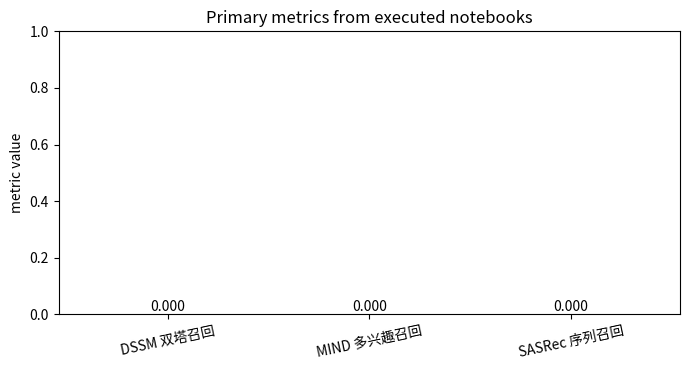

In [4]:
from matplotlib import font_manager

# Matplotlib 默认的 DejaVu Sans 不包含中文字形。优先选择容器中安装的
# Noto CJK；在精简宿主机上找不到中文字体时，退回纯 ASCII 的 Notebook 编号，
# 从根源避免 missing glyph 警告，而不是用 warnings.filterwarnings 隐藏它。
cjk_candidates = ('Noto Sans CJK SC', 'Noto Sans CJK JP', 'Microsoft YaHei', 'SimHei', 'PingFang SC')
installed_fonts = {font.name for font in font_manager.fontManager.ttflist}
cjk_font = next((name for name in cjk_candidates if name in installed_fonts), None)
if cjk_font:
    plt.rcParams['font.sans-serif'] = [cjk_font, 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
chart_labels = comparison.algorithm if cjk_font else comparison.source_notebook
print('图表字体:', cjk_font or 'ASCII fallback（宿主机未安装 CJK 字体）')

fig,ax=plt.subplots(figsize=(max(7,len(comparison)*1.5),3.8))
bars=ax.bar(chart_labels,comparison.primary_value,color='#7ca832')
ax.set(title='Primary metrics from executed notebooks',ylabel='metric value',ylim=(0,max(1.0,comparison.primary_value.max()*1.18)))
ax.tick_params(axis='x',rotation=12)
for bar,value in zip(bars,comparison.primary_value): ax.text(bar.get_x()+bar.get_width()/2,value,f'{value:.3f}',ha='center',va='bottom')
plt.tight_layout(); plt.show()

## 与原论文的可比性审计

下表逐项核对本教程实际产物与论文表格。**“不可直接比较”不是回避差距**：候选集合、样本规模、切分和指标任一不同，数值相减就没有统计含义。这里同时指出当前实验能证明什么、不能证明什么。

In [5]:
paper_audit = pd.DataFrame([{'algorithm': 'DSSM', 'source_notebook': '5_2_dssm', 'paper_result': 'NDCG@10=0.498', 'paper_protocol': '商业搜索日志训练约 1 亿 query-title 对；16,510 个查询、每个约 15 个带人工相关性标签的文档', 'verdict': '不可直接比较：任务、候选集和指标均不同；教程仅验证双塔检索链路。'}, {'algorithm': 'MIND', 'source_notebook': '5_3_mind', 'paper_result': 'Amazon Books HR@10=0.0309', 'paper_protocol': '351,356 用户、393,801 商品、6,271,511 样本；随机 19:1；K=3、d=36', 'verdict': '只有 full 档数据统计可对齐；教程时间切分比论文随机目标更严格，smoke 不参与复现。'}, {'algorithm': 'SASRec', 'source_notebook': '5_4_sasrec', 'paper_result': 'ML-1M HR@10=0.8245；NDCG@10=0.5905', 'paper_protocol': '完整读取后做 user/item 5-core；6,040 用户、3,416 物品；leave-two-out；1 真值 + 100 未观察负例；2 个自注意力块、ML-1M 序列长度 200（其余数据集 50）、d 从 {10,…,50} 调参（消融用 d=50）、默认单头（双头略差）、验证集 20 轮无提升早停', 'verdict': '协议最接近论文；只有 full profile 的最终产物可比较，smoke 不覆盖效果结论。'}])
live = comparison.copy()
live['tutorial_result'] = live.apply(
    lambda row: f"{row.primary_metric}={row.primary_value:.4f}；{row.secondary_metric}={row.secondary_value:.4f}", axis=1
)
paper_audit = paper_audit.merge(live[['source_notebook', 'tutorial_result']], on='source_notebook', how='left')
display(paper_audit[['algorithm', 'tutorial_result', 'paper_result', 'paper_protocol', 'verdict']])
print('结论：教程数值来自本次 results JSON；smoke/迁移实验不是 paper reproduction。')

,algorithm,tutorial_result,paper_result,paper_protocol,verdict
0,DSSM,recall@10=0.0000；test_auc=0.6084,NDCG@10=0.498,"商业搜索日志训练约 1 亿 query-title 对；16,510 个查询、每个约 15 ...",不可直接比较：任务、候选集和指标均不同；教程仅验证双塔检索链路。
1,MIND,recall@10=0.0000；positive_top1=0.8984,Amazon Books HR@10=0.0309,"351,356 用户、393,801 商品、6,271,511 样本；随机 19:1；K=3...",只有 full 档数据统计可对齐；教程时间切分比论文随机目标更严格，smoke 不参与复现。
2,SASRec,hr@10=0.0000；popularity_hr@10=0.0125,ML-1M HR@10=0.8245；NDCG@10=0.5905,"完整读取后做 user/item 5-core；6,040 用户、3,416 物品；leav...",协议最接近论文；只有 full profile 的最终产物可比较，smoke 不覆盖效果结论。


结论：教程数值来自本次 results JSON；smoke/迁移实验不是 paper reproduction。


## 未来发展：沿着什么约束继续前进？

未来路线不是一味堆更深网络，而是逐项解除当前系统约束。表格从左到右给出本章已经走过的变化和仍待验证的方向；最后一列是研究/工程问题，不是预告一定会获得线上提升。

In [6]:
future = pd.DataFrame([['表示数量', '单向量', '多兴趣向量', '按上下文动态表示', '可变数量兴趣 + 时序融合'], ['序列范围', '无显式次序', '行为集合软聚类', '最近 n 项因果注意力', '长序列稀疏/分层注意力与状态缓存'], ['训练信号', '随机未点击文档', 'sampled softmax', '逐位置正负 next-item', '去偏负采样、自监督预训练、多行为目标'], ['检索系统', '后续迁移到单路 ANN', 'K 路 ANN 合并', '序列用户向量 + ANN', '模型与索引联合设计、增量更新'], ['必须补测', 'Recall + 索引延迟', '覆盖/去重/每兴趣配额', '全库指标 + 长度/P99', '新鲜度、公平性、多样性、成本与线上因果收益']], columns=['dimension', 'DSSM line', 'MIND line', 'SASRec line', 'next questions'])
display(future)

,dimension,DSSM line,MIND line,SASRec line,next questions
0,表示数量,单向量,多兴趣向量,按上下文动态表示,可变数量兴趣 + 时序融合
1,序列范围,无显式次序,行为集合软聚类,最近 n 项因果注意力,长序列稀疏/分层注意力与状态缓存
2,训练信号,随机未点击文档,sampled softmax,逐位置正负 next-item,去偏负采样、自监督预训练、多行为目标
3,检索系统,后续迁移到单路 ANN,K 路 ANN 合并,序列用户向量 + ANN,模型与索引联合设计、增量更新
4,必须补测,Recall + 索引延迟,覆盖/去重/每兴趣配额,全库指标 + 长度/P99,新鲜度、公平性、多样性、成本与线上因果收益


## Takeaways

DSSM 用单向量换取简单 ANN；MIND 用多向量覆盖并行意图；SASRec 用因果注意力刻画意图随顺序的变化。三者都可输出用户向量并接全库检索，Recall 必须与 Coverage、索引成本和序列延迟一起看。

先固定业务阶段和候选口径，再比较主指标、辅助指标、baseline 与系统成本。smoke 数值用于代码回归和学习，不能跨数据或跨公司宣称优劣。

## Checks

In [7]:
assert len(comparison)==3
assert comparison.source_notebook.nunique()==3
assert comparison.primary_value.between(0,1).all()
print('PASS：总结完全来自独立 Notebook 的执行产物。')

PASS：总结完全来自独立 Notebook 的执行产物。


## Next Steps

在相同完整数据、时间切分、负样本和候选集上重跑；加入效果—延迟—成本三维表，再决定是否进入线上 A/B。